In [1]:
import pandas as pd

In [3]:
from google.colab import files

files.upload()

Saving churn-bigml-20.csv to churn-bigml-20.csv


{'churn-bigml-20.csv': b'State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn\nLA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False\nIN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.4,12.7,6,3.43,4,True\nNY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True\nSC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False\nHI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.0,1,False\nAK,36,408,No,Yes,30,146.3,128,24.87,162.5,80,13.81,129.3,109,5.82,14.5,6,3.92,0,False\nMI,65,415,No,No,0,211.3,120,35.92,162.6,122,13.82,134.7,118,6.06,13.2,5,3.56,3,False\nID,119,415,No,No,0,159.1,114,27.05,231.3,117,19.66,1

In [4]:
train_df = pd.read_csv("churn-bigml-80.csv")
test_df = pd.read_csv("churn-bigml-20.csv")

In [5]:
# Encode kolom biner
for df in [train_df, test_df]:
    df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
    df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
    df['Churn'] = df['Churn'].astype(int)

In [6]:
# One-hot encoding untuk State
train_df = pd.get_dummies(train_df, columns=['State'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['State'], drop_first=True)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]
X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9460269865067467
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       572
           1       0.98      0.63      0.77        95

    accuracy                           0.95       667
   macro avg       0.96      0.81      0.87       667
weighted avg       0.95      0.95      0.94       667



In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='recall',  # fokus ke recall karena data imbalanced
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation recall:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation recall: 0.6313686313686313


In [9]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.9505247376311844
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       572
           1       0.98      0.66      0.79        95

    accuracy                           0.95       667
   macro avg       0.97      0.83      0.88       667
weighted avg       0.95      0.95      0.95       667



In [10]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='recall')
print("Cross-validation recall scores:", cv_scores)
print("Mean CV recall:", cv_scores.mean())

Cross-validation recall scores: [0.62820513 0.51948052 0.71428571 0.62820513 0.66666667]
Mean CV recall: 0.6313686313686313


In [11]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                   Feature  Importance
5        Total day minutes    0.137973
7         Total day charge    0.118892
17  Customer service calls    0.118871
2       International plan    0.087487
10        Total eve charge    0.054571
8        Total eve minutes    0.053508
14      Total intl minutes    0.043365
15        Total intl calls    0.038436
16       Total intl charge    0.035893
13      Total night charge    0.033969


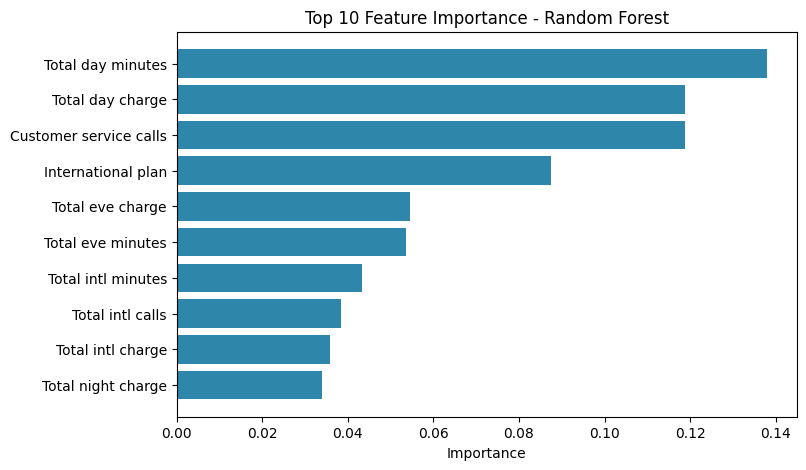

In [12]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)
plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"], color="#2E86AB")
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

## Conclusion

A Random Forest classifier was trained on the Telecom Churn dataset to predict customer churn, using the same 69 features as the Logistic Regression task.

The baseline model already outperformed Logistic Regression significantly — accuracy improved from 85.9% to 94.6%, and recall for the churn class jumped from 25% to 63%. This is because Random Forest, as an ensemble of decision trees, can capture non-linear relationships and feature interactions that a linear model like Logistic Regression cannot.

Hyperparameter tuning via GridSearchCV (optimizing for recall, given the class imbalance) found the best configuration to be `max_depth=None, min_samples_split=5, n_estimators=100`, slightly improving test recall to 66% while maintaining 98% precision. 5-fold cross-validation showed recall scores ranging from 52% to 71%, reflecting some variability due to the limited number of churn samples in the dataset.

Feature importance analysis revealed that **Total day minutes**, **Total day charge**, and **Customer service calls** were the most influential predictors — differing from Logistic Regression's top features, since Random Forest captures interaction effects rather than isolated linear relationships.

**Key takeaway:** Ensemble methods like Random Forest can substantially outperform linear models on complex, imbalanced classification tasks by capturing non-linear patterns — but recall still isn't perfect (66%), showing that further techniques (e.g., class weighting, SMOTE, or threshold tuning) could still improve real-world churn detection.